## Imports

In [16]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import  accuracy_score, precision_score, recall_score, f1_score

## Loading Data

In [2]:
# Loading train and test data
df_train = pd.read_csv("fraudTrain.csv")
df_test = pd.read_csv("fraudTest.csv")

In [3]:
# Displaying first few rows
df_train.head(), df_test.head()

(   Unnamed: 0 trans_date_trans_time            cc_num  \
 0           0   2019-01-01 00:00:18  2703186189652095   
 1           1   2019-01-01 00:00:44      630423337322   
 2           2   2019-01-01 00:00:51    38859492057661   
 3           3   2019-01-01 00:01:16  3534093764340240   
 4           4   2019-01-01 00:03:06   375534208663984   
 
                              merchant       category     amt      first  \
 0          fraud_Rippin, Kub and Mann       misc_net    4.97   Jennifer   
 1     fraud_Heller, Gutmann and Zieme    grocery_pos  107.23  Stephanie   
 2                fraud_Lind-Buckridge  entertainment  220.11     Edward   
 3  fraud_Kutch, Hermiston and Farrell  gas_transport   45.00     Jeremy   
 4                 fraud_Keeling-Crist       misc_pos   41.96      Tyler   
 
       last gender                        street  ...      lat      long  \
 0    Banks      F                561 Perry Cove  ...  36.0788  -81.1781   
 1     Gill      F  43039 Riley Greens S

### EDA

In [4]:
#Checking Data Structure
print(df_train.info())
print(df_test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [5]:
#Checking for missing values
print(df_train.isnull().sum())
print(df_test.isnull().sum())

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64
Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat            

In [6]:
# Checking fraud distribution - fraud and non-fraud

print(df_train['is_fraud'].value_counts())
print(df_test['is_fraud'].value_counts())

is_fraud
0    1289169
1       7506
Name: count, dtype: int64
is_fraud
0    553574
1      2145
Name: count, dtype: int64


### Data Preprocessing

In [7]:
# Converting 'trans_date_trans_time' to DateTime

df_train['trans_date_trans_time'] = pd.to_datetime(df_train['trans_date_trans_time'])
df_test['trans_date_trans_time'] = pd.to_datetime(df_test['trans_date_trans_time'])


In [8]:
# Encoding categorical variables

encoder = LabelEncoder()

for col in ['category', 'merchant', 'gender']:
    df_train[col] = encoder.fit_transform(df_train[col])
    df_test[col] = encoder.transform(df_test[col])

In [9]:
# Normalizing transaction amounts

scaler = MinMaxScaler()

df_train['amt'] = scaler.fit_transform(df_train[['amt']])
df_test['amt'] = scaler.transform(df_test[['amt']])

In [10]:
X = df_train.drop(columns=['is_fraud'])
y = df_train['is_fraud']

In [11]:
X['transaction_hour'] = X['trans_date_trans_time'].dt.hour
X['transaction_day'] = X['trans_date_trans_time'].dt.day
X['transaction_month'] = X['trans_date_trans_time'].dt.month
X['transaction_weekday'] = X['trans_date_trans_time'].dt.weekday
X.drop(columns=['trans_date_trans_time'], inplace=True)

In [12]:
X.drop(columns=['Unnamed: 0', 'first', 'last', 'street', 'city', 'state', 'zip', 'job', 'dob', 'trans_num'], inplace=True)

In [13]:
smote = SMOTE(sampling_strategy=0.5, random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

## Model Training

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

### Random Forest

In [15]:
# Train model
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Predictions
y_pred = clf.predict(X_test)

# Evaluate
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    257721
           1       0.99      1.00      1.00    129030

    accuracy                           1.00    386751
   macro avg       1.00      1.00      1.00    386751
weighted avg       1.00      1.00      1.00    386751



In [17]:
accuracy_rf = accuracy_score(y_test, y_pred)
precision_rf = precision_score(y_test, y_pred)
recall_rf = recall_score(y_test, y_pred)
f1_rf = f1_score(y_test, y_pred)

In [18]:
print("Random Forest Classifier:")
print("Accuracy:", accuracy_rf)
print("Precision:", precision_rf)
print("Recall:", recall_rf)
print("F1-score:", f1_rf)

Random Forest Classifier:
Accuracy: 0.9970342675261343
Precision: 0.993745318641267
Recall: 0.9973882042935751
F1-score: 0.9955634290400065


In [19]:
df_results = X_test.copy()
df_results['Actual_Fraud'] = y_test
df_results['Predicted_Fraud'] = y_pred

df_results.to_csv("fraud_predictions.csv", index=False)


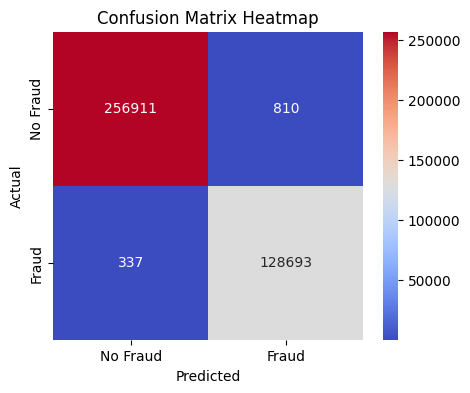

In [20]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot heatmap
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm', xticklabels=['No Fraud', 'Fraud'], yticklabels=['No Fraud', 'Fraud'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap")
plt.show()


### XGB

In [21]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
print(classification_report(y_test, y_pred_xgb))


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [02:02:09] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


              precision    recall  f1-score   support

           0       0.98      0.99      0.99    257721
           1       0.98      0.96      0.97    129030

    accuracy                           0.98    386751
   macro avg       0.98      0.98      0.98    386751
weighted avg       0.98      0.98      0.98    386751



In [22]:
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

In [23]:
print("XGBoost Classifier:")
print("Accuracy:", accuracy_xgb)
print("Precision:", precision_xgb)
print("Recall:", recall_xgb)
print("F1-score:", f1_xgb)

XGBoost Classifier:
Accuracy: 0.982241804158231
Precision: 0.9848929886955418
Recall: 0.9615205766100907
F1-score: 0.9730664554231798


In [24]:
df_results2 = X_test.copy()
df_results2['Actual_Fraud'] = y_test
df_results2['Predicted_Fraud'] = y_pred_xgb

df_results2.to_csv("fraud_predictions2.csv", index=False)

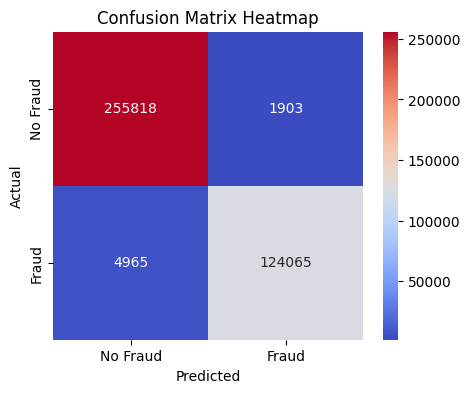

In [25]:
# Generate confusion matrix
cm2 = confusion_matrix(y_test, y_pred_xgb)

# Plot heatmap
plt.figure(figsize=(5,4))
sns.heatmap(cm2, annot=True, fmt='d', cmap='coolwarm', xticklabels=['No Fraud', 'Fraud'], yticklabels=['No Fraud', 'Fraud'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap")
plt.show()